In [1]:
from __future__ import annotations

import argparse
import json
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

In [2]:
from tremor.data import (
    CLASS_NAMES,
    Recording,
    load_recordings,
)
from tremor.evaluate import classification_report
from tremor.models import MODELS, build_model
from tremor.preprocessing import apply_stft, bandpass
from tremor.quaternion_data import load_quaternion_recordings
from tremor.spectral import (
    crop_freq_bins,
    fit_length,
    freq_bins_for_fmax,
    log_compress,
    per_freq_zscore,
    per_recording_zscore,
    spec_augment,
)

from tremor.losses import build_loss_fn
from tremor.tfd import apply_cwt, apply_hht, apply_wavelet_packet
from tremor.splits import subject_level_split
from tremor.stft_data import STFTRecording, load_stft_recordings



In [3]:
p = argparse.ArgumentParser()
p.add_argument("--data-root", required=True, type=Path)
p.add_argument("--action", default="DRINK")
p.add_argument("--data-mode",
                choices=("raw", "stft", "quaternion"), default="quaternion",
                help="'raw': time-domain amplitudes from "
                    "<feature>/<ACTION>/, STFT applied here. "
                    "'stft' (default): precomputed STFT magnitude CSVs "
                    "from <feature>/<ACTION>/<CLASS>/. "
                    "'quaternion': raw IMU quaternion CSVs from "
                    "<feature>/<ACTION>/<CLASS>/, "
                    "converted to angular velocity then STFT.")
p.add_argument("--quaternion-mode",
                choices=("angular_velocity", "components"),
                default="angular_velocity",
                help="(quaternion mode) 'angular_velocity' (default) "
                    "computes omega = 2*(dq/dt)*q^-1 per sensor -> "
                    "9 channels in rad/s. 'components' keeps the raw 12 "
                    "quaternion columns and lets the bandpass strip the "
                    "baseline orientation.")
p.add_argument("--quaternion-convention",
                choices=("xyzw", "wxyz"), default="xyzw",
                help="(quaternion mode) Component order in each 4-tuple. "
                    "Drive's raw_quaternion files use 'xyzw' (scalar last).")
p.add_argument("--feature", default="raw_quaternion",
                help="ProcessedData subfolder. For raw mode use e.g. "
                    "'filtered_amplitudes'; for stft mode use 'stft'; "
                    "for quaternion mode use 'raw_quaternion'.")
p.add_argument("--seed", type=int, default=39)
p.add_argument("--epochs", type=int, default=500)
p.add_argument("--batch-size", type=int, default=64)
p.add_argument("--lr", type=float, default=1e-3)
p.add_argument("--weight-decay", type=float, default=0.01)
p.add_argument("--model", choices=sorted(MODELS), default="tremor_bilstm",
                help="Network architecture. Options: " + ", ".join(sorted(MODELS)))
p.add_argument("--hidden", type=int, default=300,
                help="Hidden size: LSTM/GRU units for the recurrent models, "
                    "Conv1D base_filters for restcn. Used as-is — no floor "
                    "or scaling applied.")
p.add_argument("--dropout", type=float, default=0.4)
p.add_argument("--patience", type=int, default=20)
p.add_argument(
    "--oversample-to",
    type=int,
    default=None,
    help="Per-class oversampling target for the TRAINING fold only. "
            "Pass 0 or omit to disable. Pass a positive integer (e.g. 200) "
            "to draw that many samples per class with replacement.",
)
p.add_argument(
    "--auto-oversample",
    action="store_true",
    help="Override --oversample-to with 3 x the largest class count "
            "(quick way to get a roughly balanced training set).",
)
p.add_argument("--fs", type=float, default=100.0,
                help="Sampling rate in Hz of the input recordings (default 100, no downsampling).")
p.add_argument("--nperseg", type=int, default=128,
                help="STFT window length in samples (MATLAB default 128).")
p.add_argument("--nfft", type=int, default=128,
                help="STFT FFT length in samples (MATLAB default 256).")
p.add_argument("--noverlap", type=int, default=96,
                help="STFT overlap in samples (MATLAB default 96, i.e. 75%%).")
p.add_argument("--f-max", type=float, default=30,
                help="Drop STFT bins above this frequency (Hz). "
                    "Typical tremor cutoff: 15 Hz.")
p.add_argument("--apply-bandpass", action="store_true",
                help="Apply a 3-30 Hz zero-phase bandpass to each recording "
                    "before STFT (raw mode only).")
p.add_argument("--tfd-method",
                choices=("stft", "cwt", "hht", "wavelet_packet"), default="stft",
                help="Time-frequency decomposition: "
                    "'stft' (default; cheap linear-frequency spectrogram), "
                    "'cwt' (Morlet wavelet, frequency-adaptive window — "
                    "better for short non-stationary clips), "
                    "'hht' (Hilbert-Huang via EMD; best for non-stationary "
                    "tremor but slowest, needs EMD-signal), "
                    "'wavelet_packet' (dyadic sub-band energy via PyWavelets). "
                    "Used in raw and quaternion modes only.")
p.add_argument("--hht-max-imfs", type=int, default=8,
                help="(hht) Number of EMD intrinsic mode functions to keep "
                    "per channel before computing instantaneous frequency.")
p.add_argument("--wp-level", type=int, default=5,
                help="(wavelet_packet) Decomposition depth. Level 5 at "
                    "fs=100 -> 32 bands of ~1.56 Hz width each.")
p.add_argument("--wp-wavelet", default="db4",
                help="(wavelet_packet) Mother wavelet name "
                    "(db4 / sym8 / coif5 / ...).")
p.add_argument("--cwt-w0", type=float, default=6.0,
                help="(cwt) Morlet central angular frequency parameter; "
                    "higher = sharper freq resolution, longer wavelets.")
p.add_argument("--cwt-decim", type=int, default=8,
                help="(cwt) Temporal decimation factor applied to the CWT "
                    "output. With fs=100 and decim=8 the output frame "
                    "rate is 12.5 Hz, comparable to the STFT's hop=32.")
p.add_argument("--cwt-freq-step", type=float, default=0.5,
                help="(cwt) Spacing between analysis frequencies in Hz, "
                    "swept from 3 Hz to --f-max. Step 0.5 -> ~24 bins; "
                    "step 0.25 -> ~48 bins.")
p.add_argument("--length-mode", choices=("truncate", "pad"), default="truncate",
                help="How to make all recordings the same length. "
                    "'truncate' (default): target = min_length; long "
                    "recordings get randomly cropped (train) or centre-"
                    "cropped (val/test) — no padding. "
                    "'pad': target = max_length; short recordings get "
                    "zero-padded according to --pad-mode.")
p.add_argument("--pad-mode", choices=("random", "center"), default="random",
                help="(pad mode only) Where to place the signal inside the "
                    "padded window. 'random' (default) picks a random "
                    "offset per training sample — acts as a time-shift "
                    "augmentation. 'center' places it dead centre, no "
                    "randomness. Val/test always uses centre regardless.")
p.add_argument("--stft-fs", type=float, default=100.0,
                help="(stft mode) Original sampling rate the STFTs were "
                    "computed at — used to map --f-max to bin count.")
p.add_argument("--stft-n-sensors", type=int, default=3,
                help="(stft mode) Number of sensors stacked column-wise.")
p.add_argument("--stft-n-freq-bins", type=int, default=65,
                help="(stft mode) Frequency bins per sensor (nfft/2+1).")
p.add_argument("--no-log-compress", action="store_true",
                help="Disable log1p magnitude compression of the spectrogram.")
p.add_argument("--normalize",
                choices=("none", "per_freq", "per_recording"),
                default="per_recording",
                help="Per-recording normalization applied after the TFD. "
                    "'per_recording' (default) z-scores over all bins of a "
                    "recording — preserves the spectral magnitude profile "
                    "that distinguishes PD (3-7 Hz) from ET (4-12 Hz). "
                    "'per_freq' z-scores each frequency row across time "
                    "and DESTROYS the spectral peak for quasi-stationary "
                    "tremors; only useful for non-stationary action data. "
                    "'none' relies entirely on the model's input BatchNorm.")
p.add_argument("--spec-augment", action="store_true",
                help="SpecAugment freq/time masking on TRAIN only.")
p.add_argument("--loss", choices=("ce", "weighted_ce", "focal"),
                default="focal",
                help="Loss function. 'ce' is plain cross-entropy. "
                    "'weighted_ce' adds inverse-frequency class weights "
                    "(handles class imbalance). 'focal' (default) adds "
                    "the (1-p_t)^gamma down-weight on top of weighted_ce "
                    "to focus on hard examples.")
p.add_argument("--focal-gamma", type=float, default=1.5,
                help="Focusing parameter for focal loss. 0 = weighted CE; "
                    "1-2.5 are typical for moderately imbalanced 3-class "
                    "problems.")
p.add_argument("--label-smoothing", type=float, default=0.0,
                help="Label smoothing for the loss. 0.05-0.1 is a mild "
                    "regulariser; values >= 0.2 can hurt accuracy.")
p.add_argument("--output", type=Path, default=Path("artifacts"))
args = p.parse_args([
    "--data-root", "C:/Users/PC/YuXuan/TremorClassification2/Data",
    "--action", "OUT",
    "--data-mode", "quaternion"
])

def _seed_everything(seed: int) -> None:
    """Seed every RNG the training run touches.

    - ``torch.manual_seed``     -> model init, dropout, BatchNorm running stats
    - ``torch.cuda.manual_seed_all`` -> all GPU RNGs (no-op on CPU)
    - ``np.random.seed``        -> legacy numpy global RNG
    - ``random.seed``           -> Python stdlib RNG (defensive; not used here)

    The per-dataset ``np.random.default_rng`` instances (oversampling,
    random padding, SpecAugment) are seeded separately with
    ``args.seed`` / ``+1`` / ``+2`` for train / val / test so that
    augmentation order is also reproducible.
    """
    import random as _stdrandom
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    _stdrandom.seed(seed)
    print(f"[seed] all RNGs seeded with {seed}")

_seed_everything(args.seed)
args.output.mkdir(parents=True, exist_ok=True)

[seed] all RNGs seeded with 39


In [ ]:
def _load_recordings_for_mode(args):
    """Dispatch to the right loader based on ``--data-mode``.

    Raises FileNotFoundError when the expected folder isn't present.
    Returns a list of Recording / STFTRecording objects.
    """
    if args.data_mode == "raw":
        recs = load_recordings(
            args.data_root, feature=args.feature, action=args.action,
        )
        if not recs:
            raise FileNotFoundError(
                f"No recordings under {args.feature}/{args.action}."
            )
        return recs

    if args.data_mode == "quaternion":
        feature = args.feature if args.feature != "stft" else "raw_quaternion"
        recs = load_quaternion_recordings(
            args.data_root, action=args.action, fs=args.fs,
            mode=args.quaternion_mode, convention=args.quaternion_convention,
            feature=feature,
        )
        if not recs:
            raise FileNotFoundError(
                f"No quaternion files under {feature}/{args.action}."
            )
        return recs

    recs = load_stft_recordings(
        args.data_root, action=args.action, feature=args.feature,
    )
    if not recs:
        raise FileNotFoundError(
            f"No STFT files under {args.feature}/{args.action}."
        )
    return recs

recs = _load_recordings_for_mode(args)

In [ ]:
for r in recs:
    r.x = bandpass(r.x, fs=args.fs, band=(3.0, 30.0))

In [ ]:
def _oversample_per_class(recs, oversample_to, rng):
    """Oversample each class to ``oversample_to`` items.

    Returns the original list unchanged when ``oversample_to`` is None.
    Empty classes are skipped (they cannot be sampled from) instead of
    raising — set up that case with a clear message at the call site.
    """
    if oversample_to is None or oversample_to <= 0:
        return list(recs)
    by_class: dict[int, list] = {}
    for r in recs:
        by_class.setdefault(r.y, []).append(r)
    balanced = []
    for cls, items in by_class.items():
        if not items:
            continue
        idx = rng.integers(0, len(items), size=oversample_to)
        balanced.extend(items[i] for i in idx)
    return balanced

from tremor.datasets import TremorDataset    

lengths = [r.x.shape[1] for r in recs]
target_length = int(min(lengths))

ds_kwargs = dict(
            fs=args.fs,
            nperseg=args.nperseg,
            nfft=args.nfft,
            noverlap=args.noverlap,
            f_max=args.f_max,
            tfd_method='stft',
            cwt_w0=args.cwt_w0,
            cwt_decim=args.cwt_decim,
            cwt_freq_step=args.cwt_freq_step,
            hht_max_imfs=args.hht_max_imfs,
            wp_level=args.wp_level,
            wp_wavelet=args.wp_wavelet,
            log_compress_on=not args.no_log_compress,
            normalize=args.normalize,
            spec_augment_on=args.spec_augment,
            length_mode=args.length_mode,
            pad_mode=args.pad_mode,
        )

train_ds = TremorDataset(
        recs, target_length=target_length, rng_seed=args.seed,
        oversample_to=args.oversample_to, augment=True, **ds_kwargs,
    )

In [ ]:
train_loader = DataLoader(
    train_ds, batch_size=args.batch_size, shuffle=True, drop_last=False
)

Graph 1 (Index 26) Shape: torch.Size([351, 29])
Graph 2 (Index 33) Shape: torch.Size([351, 29])
Graph 3 (Index 49) Shape: torch.Size([351, 29])
Graph 4 (Index 3) Shape: torch.Size([351, 29])


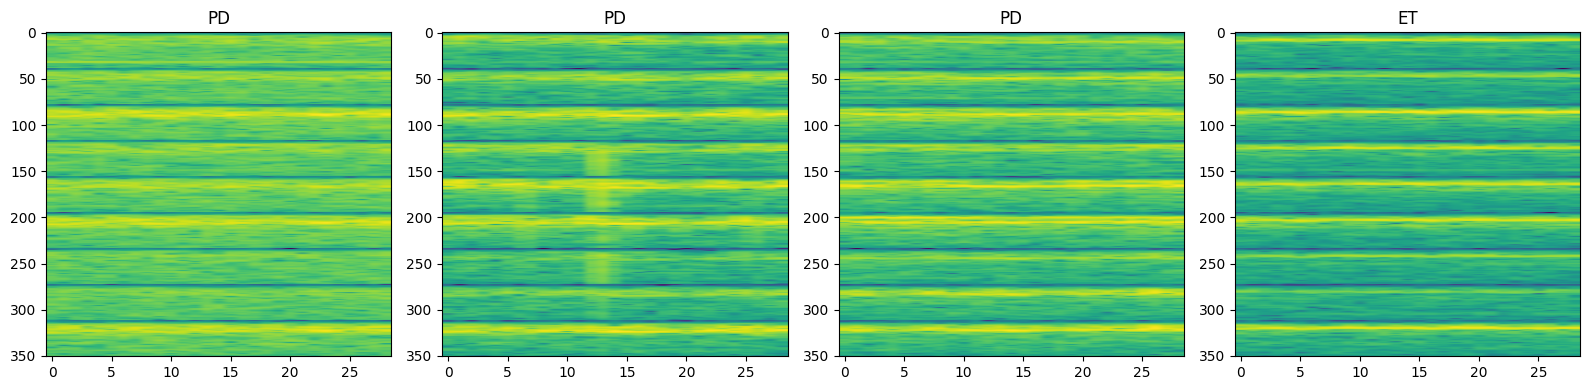

In [ ]:
import random
import matplotlib.pyplot as plt

# 1. Fetch a batch of data
x, y = next(iter(train_loader))
batch_size = x.shape[0]

# 2. Randomly select 4 distinct indices from the batch
random_indices = random.sample(range(batch_size), k=min(4, batch_size))

# 3. Plot the 4 random images in a row
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, N in enumerate(random_indices):
    # Get the image data (without transpose, per your update)
    img_data = x[N]
    
    # Print the shape for debugging/verification
    print(f"Graph {i+1} (Index {N}) Shape: {img_data.shape}")
    
    # Plotting
    axes[i].imshow(img_data, aspect="auto", origin="lower", cmap='viridis')
    axes[i].set_title(CLASS_NAMES[y[N]])
    
    # FIX: Invert the y-axis for EACH subplot individually
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()